# Chapter 9 - Sources

## Source Span

This notebook covers **Computational Geometry in C**, Chapter 9, printed pages 347-367: bibliographies and FAQs, textbooks, book collections, monographs, journals, conference proceedings, software resources, and the bibliography/index tail of the book. The source chapter is not a theorem chapter, so the notebook treats it as a reproducible research map. A student who has finished the algorithm chapters needs to know where to look next, which sources answer which kinds of questions, and how software resources connect back to the primitives built earlier in the course.

The chapter names three high-value entry points for most readers: a handbook for short surveys, a community bibliography for bibliographic search, and a computational geometry software directory for implementations. It then expands outward into categories. Bibliographies and FAQs help discover papers and common algorithm questions. Textbooks provide coherent routes through the field, with some emphasizing search structures, arrangements, randomized algorithms, parallel algorithms, or classic algorithmic foundations. Collections and handbooks supply survey chapters. Monographs focus deeply on specialized topics such as art gallery theorems, motion planning, projective geometry, or related discrete geometry. Journals and conferences are the primary research stream. Software resources remind the reader that robustness, predicates, and reusable libraries are part of computational geometry, not an afterthought.

The visuals below turn that prose into a graph, a timeline, a topic-to-source matrix, and a software-dependency ledger. The intent is standalone orientation rather than copied bibliographic detail.


## Visual Storyboard

1. **Source ecosystem graph.** Resource categories connect to the earlier algorithm chapters and to the three practical entry points emphasized in the source span.
2. **Historical timeline.** Textbooks, conferences, handbooks, and software milestones are placed on a compact timeline to show how the field matured.
3. **Topic-source matrix.** A heatmap routes course topics such as triangulation, hulls, Voronoi, arrangements, intersection, and motion planning to the source categories most likely to help.
4. **Software ledger.** Qhull-like hull/Voronoi tools, LEDA-like libraries, book code, and algorithm repositories are classified by what they support and what risks they do not automatically solve.
5. **Reading plan generator.** A small table turns a learning goal into a recommended sequence of source types.
6. **Coverage check.** A JSON ledger records every section 9.1-9.7 and ties it to at least one artifact.


## Library Routing

This chapter uses `networkx` for the source graph, `matplotlib` for graph/timeline/heatmap figures, and book-local helpers for auditable outputs. There is no need for computational geometry libraries here. The computation is a structure check: every resource category should have a role, every previous algorithm chapter should be routeable to sources, and the software discussion should explicitly keep robustness and predicate risk visible.


In [1]:
# setup
from __future__ import annotations
import json, sys
from pathlib import Path

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

BOOK_ROOT = Path.cwd()
while not ((BOOK_ROOT / "AGENTS.md").exists() and (BOOK_ROOT / "source_map.json").exists()):
    if BOOK_ROOT.parent == BOOK_ROOT:
        raise RuntimeError("Could not locate Computational-Geometry-in-C root")
    BOOK_ROOT = BOOK_ROOT.parent
if str(BOOK_ROOT) not in sys.path:
    sys.path.insert(0, str(BOOK_ROOT))

from utils.artifacts import assert_artifacts, chapter_artifact_root, display_artifact, save_csv, save_json, save_matplotlib

UNIT_KEY = "chapter-09-sources"
UNIT_TITLE = "Sources"
ARTIFACT_ROOT = chapter_artifact_root(UNIT_KEY, BOOK_ROOT)
FIGURES = ARTIFACT_ROOT / "figures"
CHECKS = ARTIFACT_ROOT / "checks"
TABLES = ARTIFACT_ROOT / "tables"

sections = [
    {"section": "9.1", "title": "Bibliographies and FAQs", "artifact": "source-ecosystem-graph.png"},
    {"section": "9.2", "title": "Textbooks", "artifact": "source-topic-matrix.png"},
    {"section": "9.3", "title": "Book Collections", "artifact": "source-timeline.png"},
    {"section": "9.4", "title": "Monographs", "artifact": "source-topic-matrix.png"},
    {"section": "9.5", "title": "Journals", "artifact": "source-ecosystem-graph.png"},
    {"section": "9.6", "title": "Conference Proceedings", "artifact": "source-timeline.png"},
    {"section": "9.7", "title": "Software", "artifact": "software-resource-ledger.png"},
]
storyboard = [
    {"move": "source graph", "visual": "source-ecosystem-graph.png", "check": "all_categories_connected"},
    {"move": "timeline", "visual": "source-timeline.png", "check": "timeline_has_conferences_and_software"},
    {"move": "topic matrix", "visual": "source-topic-matrix.png", "check": "each_topic_has_route"},
    {"move": "software ledger", "visual": "software-resource-ledger.png", "check": "software_rows_include_robustness_note"},
    {"move": "reading plan", "visual": "reading-plan-table.csv", "check": "plans_cover_all_learning_goals"},
]
routing_rows = [
    {"source_section": row["section"], "category": row["title"], "artifact": row["artifact"]} for row in sections
]
storyboard_path = save_json({"unit": UNIT_TITLE, "source_span": "printed pages 347-367", "storyboard": storyboard}, CHECKS / "visual-storyboard.json")
routing_path = save_csv(routing_rows, TABLES / "library-routing.csv")
coverage_path = save_json({
    "unit": UNIT_TITLE,
    "source_span": {"printed_pages": "347-367", "pdf_pages": "356-376"},
    "covered_sections": sections,
    "note": "Bibliographic names are summarized by category and role; the notebook does not copy long lists from the source chapter.",
}, CHECKS / "source-coverage.json")
print(json.dumps({"artifact_root": str(ARTIFACT_ROOT), "sections": len(sections)}, indent=2))


{
  "artifact_root": "D:\\Geometry\\Computational-Geometry-in-C\\artifacts\\chapter-09-sources",
  "sections": 7
}


## Source Ecosystem Graph

The first useful move is to stop treating the chapter as a flat list. The resources have different jobs. A bibliography is for finding papers. A FAQ is for common implementation questions and folklore. A textbook is for a sustained path through definitions and algorithms. A handbook or edited collection is for surveys. A monograph is for depth on one subject. Journals and conferences are where new results appear. Software resources connect theory to robust predicates, data structures, and tested implementations.

The graph below also connects those categories back to the earlier chapters. Triangulation and art gallery problems naturally point to monographs and textbooks. Convex hulls and Voronoi diagrams point to software as well as textbooks. Arrangements require deeper texts and research surveys. Motion planning pulls in monographs, proceedings, and software. This graph is the chapter's main standalone artifact: it tells a reader where to go next based on the kind of question they have.


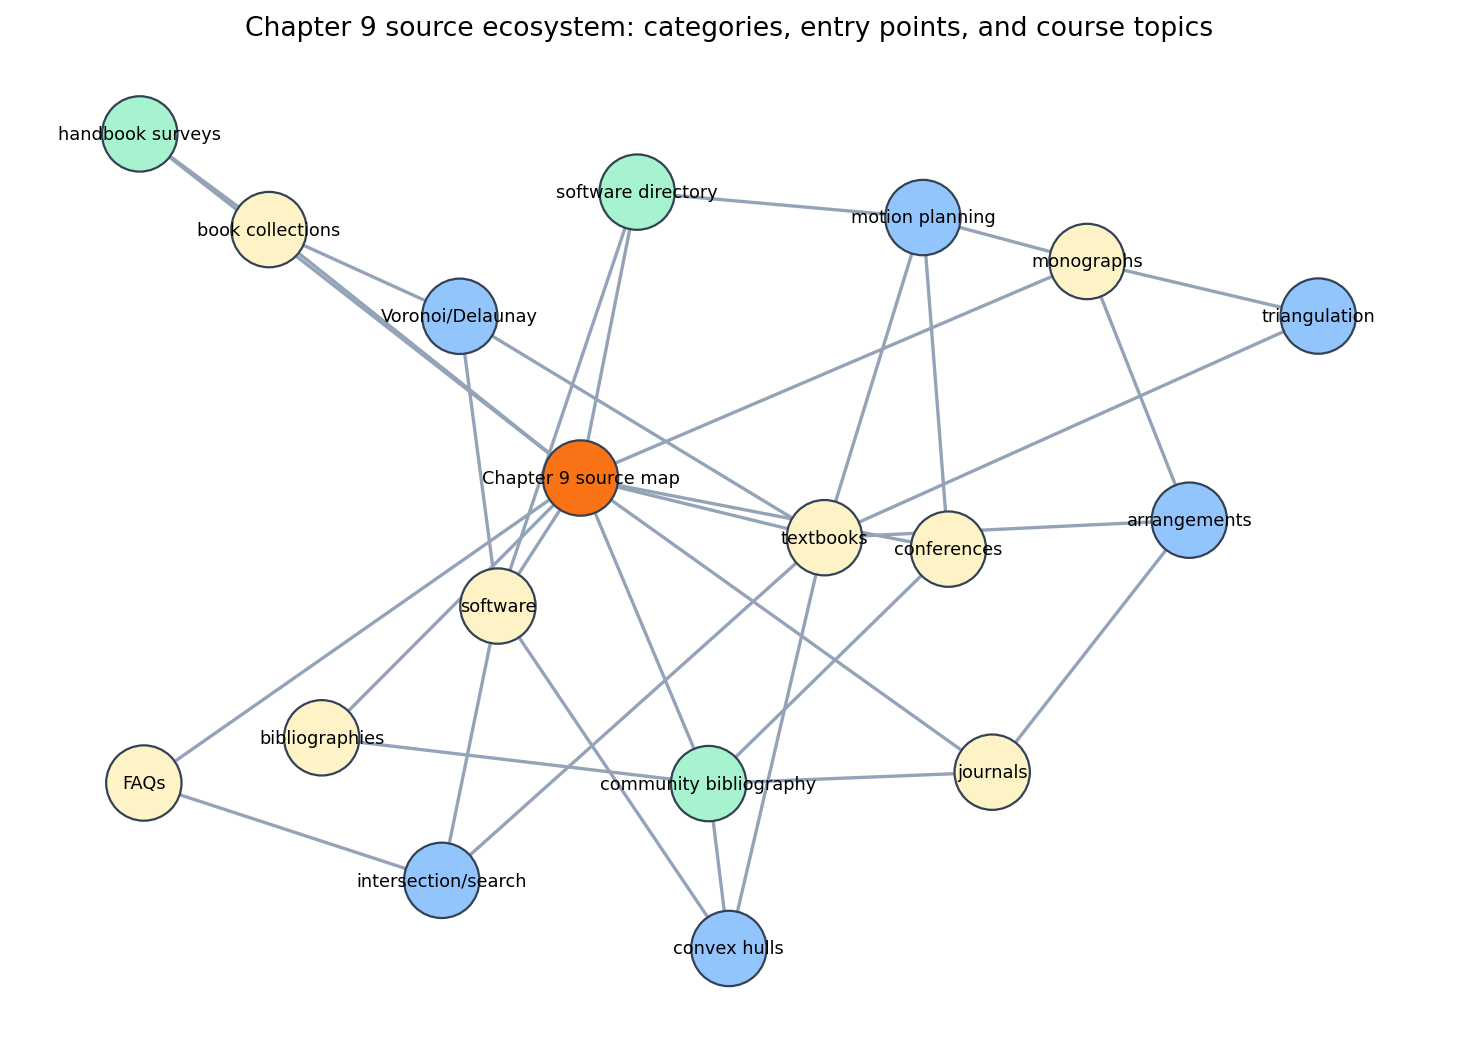

In [2]:
entry_points = ["handbook surveys", "community bibliography", "software directory"]
categories = ["bibliographies", "FAQs", "textbooks", "book collections", "monographs", "journals", "conferences", "software"]
topics = ["triangulation", "convex hulls", "Voronoi/Delaunay", "arrangements", "intersection/search", "motion planning"]
G = nx.Graph()
G.add_node("Chapter 9 source map", kind="center")
for node in entry_points:
    G.add_edge("Chapter 9 source map", node, relation="entry point")
for node in categories:
    G.add_edge("Chapter 9 source map", node, relation="category")
for topic in topics:
    G.add_edge(topic, "textbooks", relation="course route")
G.add_edges_from([
    ("triangulation", "monographs"),
    ("convex hulls", "software"),
    ("convex hulls", "community bibliography"),
    ("Voronoi/Delaunay", "software"),
    ("Voronoi/Delaunay", "book collections"),
    ("arrangements", "monographs"),
    ("arrangements", "journals"),
    ("intersection/search", "FAQs"),
    ("intersection/search", "software"),
    ("motion planning", "conferences"),
    ("motion planning", "monographs"),
    ("motion planning", "software directory"),
    ("handbook surveys", "book collections"),
    ("community bibliography", "bibliographies"),
    ("software directory", "software"),
    ("journals", "community bibliography"),
    ("conferences", "community bibliography"),
])

pos = nx.spring_layout(G, seed=22, k=0.72)
kind_colors = []
for node in G.nodes:
    if node == "Chapter 9 source map":
        kind_colors.append("#f97316")
    elif node in topics:
        kind_colors.append("#93c5fd")
    elif node in entry_points:
        kind_colors.append("#a7f3d0")
    else:
        kind_colors.append("#fef3c7")
fig, ax = plt.subplots(figsize=(11.5, 8.0))
nx.draw_networkx_edges(G, pos, ax=ax, edge_color="#94a3b8", width=1.5)
nx.draw_networkx_nodes(G, pos, node_color=kind_colors, edgecolors="#334155", node_size=1150, ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
ax.set_title("Chapter 9 source ecosystem: categories, entry points, and course topics")
ax.axis("off")
graph_fig_path = save_matplotlib(fig, FIGURES / "source-ecosystem-graph.png")
plt.close(fig)

graph_report_path = save_json({
    "nodes": list(G.nodes),
    "edges": [[u, v] for u, v in G.edges],
    "checks": {
        "all_categories_connected": all(nx.has_path(G, "Chapter 9 source map", c) for c in categories),
        "all_topics_have_routes": all(G.degree(t) >= 2 for t in topics),
        "entry_points_present": all(e in G for e in entry_points),
    },
}, CHECKS / "source-ecosystem-graph.json")
display_artifact(graph_fig_path, width=950)


## Timeline and Topic Matrix

The timeline is not a claim about the latest state of the field; it is a source-span map of the historical resources named by the chapter. It shows why the chapter emphasizes proceedings and bibliographies: computational geometry was still young enough that primary literature mattered heavily. The matrix then asks a practical question: if a learner wants to deepen a topic from this course, which source category is most useful first?


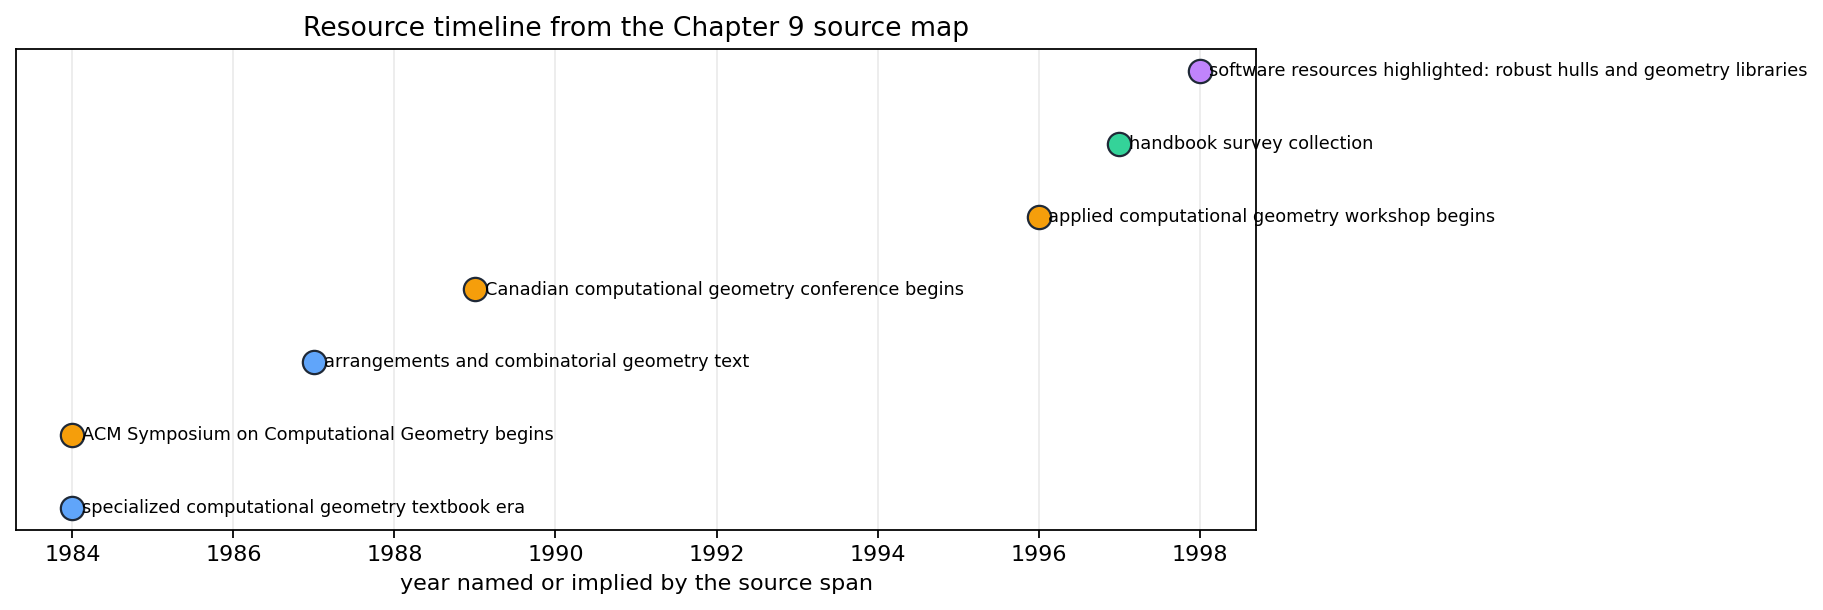

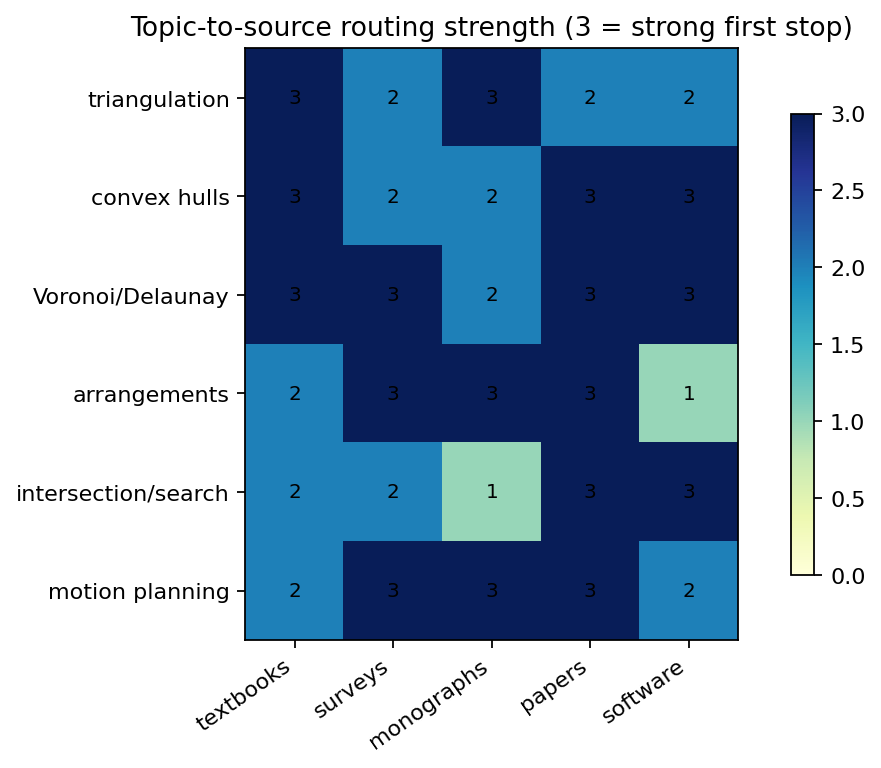

In [3]:
timeline_rows = [
    {"year": 1984, "item": "specialized computational geometry textbook era", "type": "textbook"},
    {"year": 1984, "item": "ACM Symposium on Computational Geometry begins", "type": "conference"},
    {"year": 1987, "item": "arrangements and combinatorial geometry text", "type": "textbook"},
    {"year": 1989, "item": "Canadian computational geometry conference begins", "type": "conference"},
    {"year": 1996, "item": "applied computational geometry workshop begins", "type": "conference"},
    {"year": 1997, "item": "handbook survey collection", "type": "collection"},
    {"year": 1998, "item": "software resources highlighted: robust hulls and geometry libraries", "type": "software"},
]
timeline_table_path = save_csv(timeline_rows, TABLES / "source-timeline.csv")
colors = {"textbook": "#60a5fa", "conference": "#f59e0b", "collection": "#34d399", "software": "#c084fc"}
fig, ax = plt.subplots(figsize=(10, 3.9))
for i, row in enumerate(timeline_rows):
    ax.scatter(row["year"], i, color=colors[row["type"]], s=110, edgecolor="#1f2937", zorder=3)
    ax.text(row["year"] + 0.12, i, row["item"], va="center", fontsize=8)
ax.set_yticks([])
ax.set_xlabel("year named or implied by the source span")
ax.set_title("Resource timeline from the Chapter 9 source map")
ax.grid(True, axis="x", alpha=0.25)
timeline_fig_path = save_matplotlib(fig, FIGURES / "source-timeline.png")
plt.close(fig)

matrix_categories = ["textbooks", "surveys", "monographs", "papers", "software"]
weights = np.array([
    [3, 2, 3, 2, 2],  # triangulation
    [3, 2, 2, 3, 3],  # hulls
    [3, 3, 2, 3, 3],  # voronoi
    [2, 3, 3, 3, 1],  # arrangements
    [2, 2, 1, 3, 3],  # intersection/search
    [2, 3, 3, 3, 2],  # motion planning
], dtype=float)
fig, ax = plt.subplots(figsize=(8.6, 4.8))
im = ax.imshow(weights, cmap="YlGnBu", vmin=0, vmax=3)
ax.set_xticks(range(len(matrix_categories)), matrix_categories, rotation=35, ha="right")
ax.set_yticks(range(len(topics)), topics)
for i in range(weights.shape[0]):
    for j in range(weights.shape[1]):
        ax.text(j, i, int(weights[i, j]), ha="center", va="center", fontsize=9)
ax.set_title("Topic-to-source routing strength (3 = strong first stop)")
fig.colorbar(im, ax=ax, shrink=0.78)
matrix_fig_path = save_matplotlib(fig, FIGURES / "source-topic-matrix.png")
plt.close(fig)

matrix_rows = []
for topic, row in zip(topics, weights):
    for category, score in zip(matrix_categories, row):
        matrix_rows.append({"topic": topic, "source_category": category, "routing_strength": int(score)})
matrix_table_path = save_csv(matrix_rows, TABLES / "source-topic-matrix.csv")
timeline_report_path = save_json({
    "timeline_items": timeline_rows,
    "checks": {
        "timeline_has_conferences_and_software": any(r["type"] == "conference" for r in timeline_rows) and any(r["type"] == "software" for r in timeline_rows),
        "each_topic_has_route": all(weights[i].max() == 3 for i in range(len(topics))),
    },
}, CHECKS / "timeline-and-topic-matrix.json")
display_artifact(timeline_fig_path, width=880)
display_artifact(matrix_fig_path, width=760)


## Software Resource Ledger

The software section matters because the rest of the book repeatedly warns about implementation detail: overflow, degeneracy, exact predicates, data structures, and representation choices. A hull program or geometry library can save time, but it does not absolve the user from understanding assumptions. The ledger below separates capability from caution. It is written generically from the source chapter's categories rather than as a current web directory.


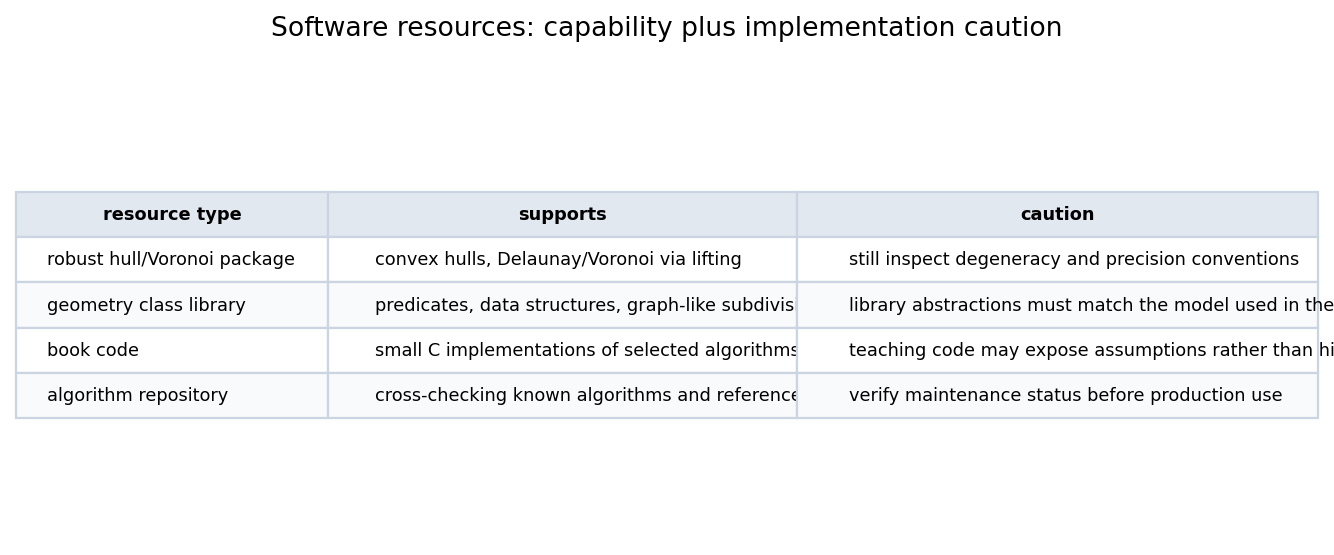

In [4]:
software_rows = [
    {"resource_type": "robust hull/Voronoi package", "supports": "convex hulls, Delaunay/Voronoi via lifting", "course_links": "Chapters 3-5", "robustness_note": "still inspect degeneracy and precision conventions"},
    {"resource_type": "geometry class library", "supports": "predicates, data structures, graph-like subdivisions", "course_links": "Chapters 1-8", "robustness_note": "library abstractions must match the model used in the proof"},
    {"resource_type": "book code", "supports": "small C implementations of selected algorithms", "course_links": "implementation sections", "robustness_note": "teaching code may expose assumptions rather than hide them"},
    {"resource_type": "algorithm repository", "supports": "cross-checking known algorithms and references", "course_links": "all chapters", "robustness_note": "verify maintenance status before production use"},
]
software_table_path = save_csv(software_rows, TABLES / "software-resource-ledger.csv")

fig, ax = plt.subplots(figsize=(10.5, 3.8))
ax.axis("off")
cell_text = [[row["resource_type"], row["supports"], row["robustness_note"]] for row in software_rows]
table = ax.table(cellText=cell_text, colLabels=["resource type", "supports", "caution"], cellLoc="left", loc="center", colWidths=[0.24, 0.36, 0.40])
table.auto_set_font_size(False)
table.set_fontsize(8)
table.scale(1, 1.7)
for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor("#cbd5e1")
    if r == 0:
        cell.set_facecolor("#e2e8f0")
        cell.set_text_props(weight="bold")
    elif r % 2 == 0:
        cell.set_facecolor("#f8fafc")
ax.set_title("Software resources: capability plus implementation caution", pad=16)
software_fig_path = save_matplotlib(fig, FIGURES / "software-resource-ledger.png")
plt.close(fig)

reading_plan_rows = [
    {"learning_goal": "find a quick overview", "first_source": "handbook or survey collection", "then_use": "bibliography for primary papers"},
    {"learning_goal": "implement an algorithm", "first_source": "textbook and book code", "then_use": "software directory or geometry library"},
    {"learning_goal": "study arrangements deeply", "first_source": "specialized text or monograph", "then_use": "journal/conference papers"},
    {"learning_goal": "track current research direction", "first_source": "conference proceedings", "then_use": "community bibliography and journals"},
    {"learning_goal": "choose robust tooling", "first_source": "software directory", "then_use": "documentation plus predicate tests from earlier chapters"},
]
reading_plan_path = save_csv(reading_plan_rows, TABLES / "reading-plan-table.csv")
software_report_path = save_json({
    "software_rows": software_rows,
    "reading_plan_goals": [row["learning_goal"] for row in reading_plan_rows],
    "checks": {
        "software_rows_include_robustness_note": all(row["robustness_note"] for row in software_rows),
        "plans_cover_all_learning_goals": len(reading_plan_rows) >= 5,
        "software_section_tied_to_prior_chapters": all(row["course_links"] for row in software_rows),
    },
}, CHECKS / "software-and-reading-plan.json")
display_artifact(software_fig_path, width=900)


## Applied Lab

Pick one algorithm from Chapters 1-8 and build a three-source reading path. For example, for Voronoi diagrams, start with a textbook account of definitions and Delaunay duality, read a survey or handbook chapter for variants and applications, then inspect software documentation for degeneracy handling. For arrangements, begin with a specialized text or survey because the abstraction level is higher, then use proceedings or journals to follow applications such as hidden-surface removal or ham-sandwich cuts.

The lab is deliberately about choosing sources, not memorizing a bibliography. A good source plan should answer three questions: what concept do I need clarified, what implementation risk do I need reduced, and what research direction do I need to follow?


## Takeaways

Chapter 9 is the course's map outward. It says that computational geometry is too broad and too active to be captured by one book. Bibliographies and FAQs help with discovery. Textbooks and collections provide coherent explanations. Monographs provide depth. Journals and conferences carry the frontier. Software resources turn theory into reusable machinery, but they must be used with awareness of predicates, degeneracies, and data structure assumptions.

The notebook's checks are modest but important: every source section is represented, every major course topic has a source route, the timeline includes research venues and software, and the software ledger includes a robustness note. That makes the source chapter executable in spirit: the output is a reproducible plan for continuing the study of computational geometry.


In [5]:
# final_sanity
coverage_sections = {row["section"] for row in sections}
final_sanity = {
    "unit": UNIT_TITLE,
    "artifact_count": 11,
    "checks": {
        "all_sections_9_1_to_9_7_covered": coverage_sections == {"9.1", "9.2", "9.3", "9.4", "9.5", "9.6", "9.7"},
        "all_categories_connected": all(nx.has_path(G, "Chapter 9 source map", c) for c in categories),
        "entry_points_present": all(e in G for e in entry_points),
        "timeline_has_conferences_and_software": any(r["type"] == "conference" for r in timeline_rows) and any(r["type"] == "software" for r in timeline_rows),
        "each_topic_has_route": all(weights[i].max() == 3 for i in range(len(topics))),
        "software_rows_include_robustness_note": all(row["robustness_note"] for row in software_rows),
        "plans_cover_all_learning_goals": len(reading_plan_rows) >= 5,
    },
    "artifacts": [
        str(storyboard_path), str(routing_path), str(coverage_path), str(graph_fig_path), str(graph_report_path),
        str(timeline_table_path), str(timeline_fig_path), str(matrix_fig_path), str(matrix_table_path), str(timeline_report_path),
        str(software_table_path), str(software_fig_path), str(reading_plan_path), str(software_report_path),
    ],
}
final_sanity_path = save_json(final_sanity, CHECKS / "final-sanity.json")
assert all(final_sanity["checks"].values()), json.dumps(final_sanity["checks"], indent=2)
assert_artifacts([Path(p) for p in final_sanity["artifacts"]] + [final_sanity_path], min_bytes=40)
print(json.dumps({"final_sanity": "passed", "checks": final_sanity["checks"]}, indent=2))


{
  "final_sanity": "passed",
  "checks": {
    "all_sections_9_1_to_9_7_covered": true,
    "all_categories_connected": true,
    "entry_points_present": true,
    "timeline_has_conferences_and_software": true,
    "each_topic_has_route": true,
    "software_rows_include_robustness_note": true,
    "plans_cover_all_learning_goals": true
  }
}
